# Valid Frames

This notebook checks the valid frames for responses and videos across recordings

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from ssdatam.dataset import DataSet

Define the paths used to access data and metadata.

In [27]:
repo_root = Path.cwd().parent

# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [28]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             check=False,
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"



Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons fo

# Valid Responses

In [29]:
# valid responses per recording
trials_df = ds.trials_df.copy()
trials_df["recording_short_label"] = trials_df["recording"].map(mapping)
print("Number of valid responses per recording:")
trials_df[trials_df["valid_response"]].groupby("recording_short_label").size()

Number of valid responses per recording:


recording_short_label
rec-29156-11-10    720
rec-29228-2-10     704
rec-29234-6-9      729
rec-29513-3-5      714
rec-29514-2-9      723
rec-29515-10-12    406
rec-29623-4-9      385
rec-29647-19-8     414
rec-29712-5-9      419
rec-29755-2-8      413
dtype: int64

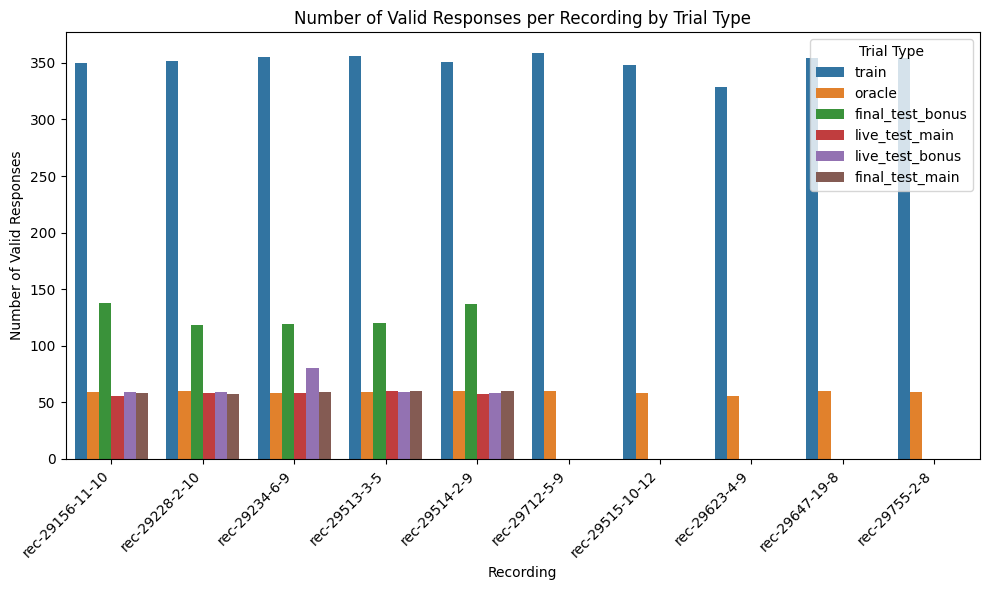

In [30]:
# plot a bar plot of the number of valid responses per recording separated by trial_type (as hue)
plt.figure(figsize=(10, 6))
sns.countplot(data=trials_df[trials_df["valid_response"]], x="recording_short_label", hue="trial_type")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Recording")
plt.ylabel("Number of Valid Responses")
plt.title("Number of Valid Responses per Recording by Trial Type")
plt.legend(title="Trial Type")
plt.tight_layout()
plt.show()

## Valid frames per label

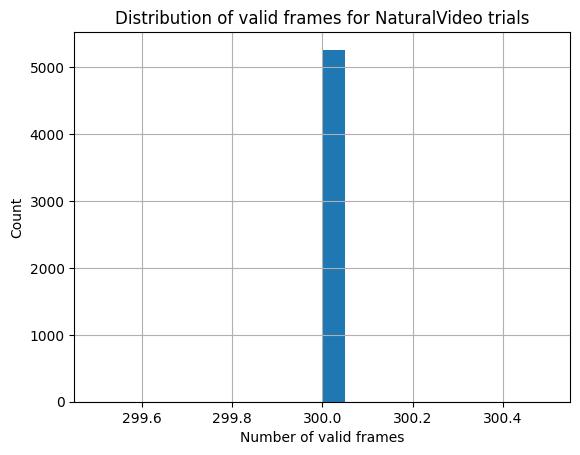

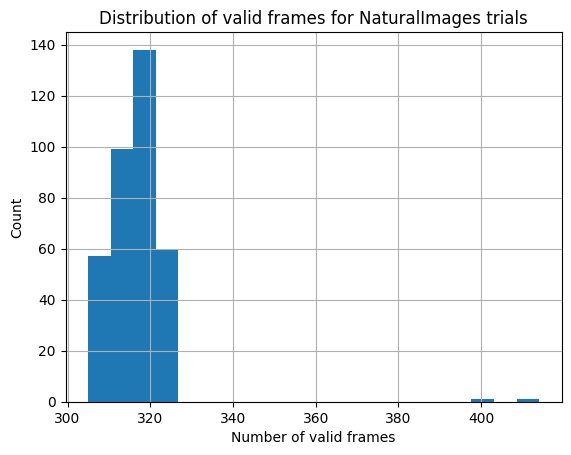

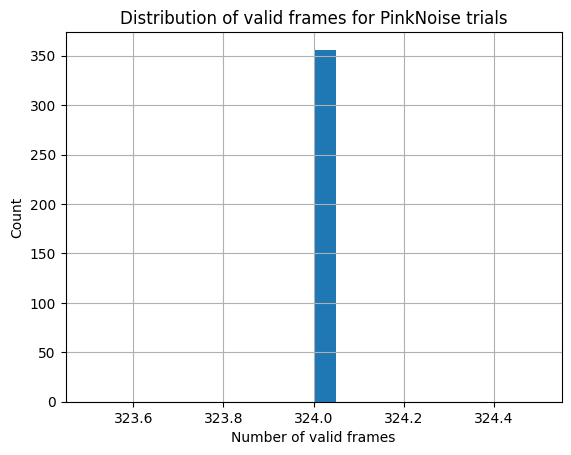

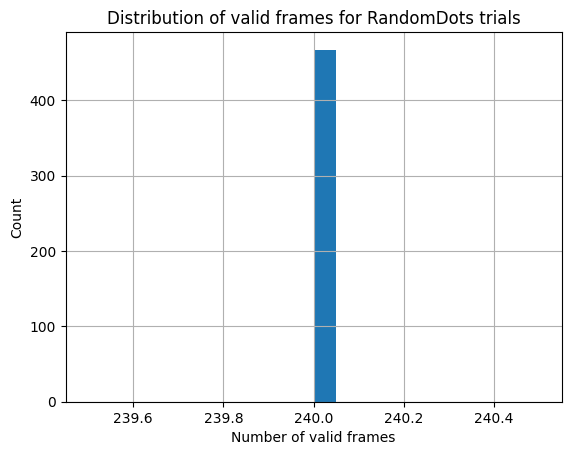

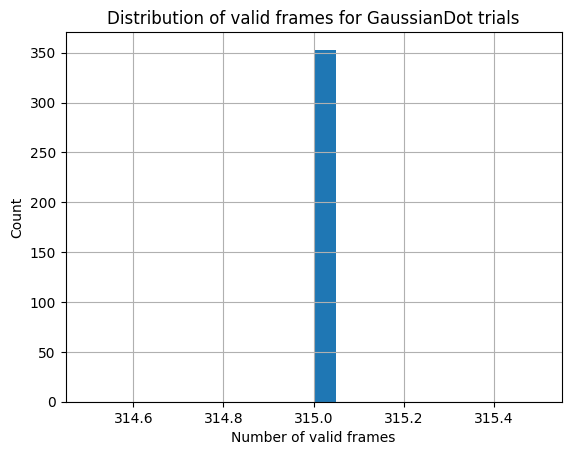

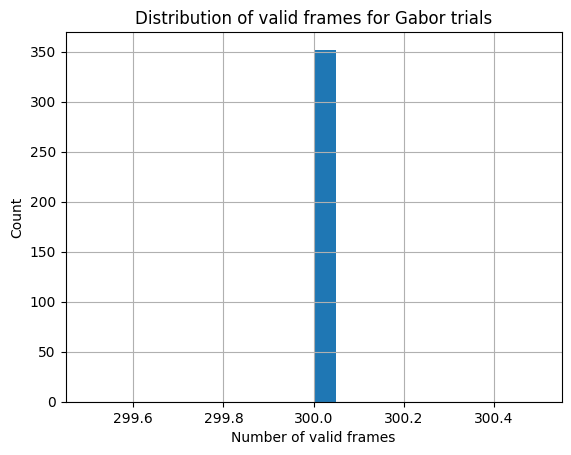

In [31]:
trials_df = ds.trials_df.copy()
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]

for lab in labels_order:
    trials_df[trials_df["label"] == lab]["valid_frames"].hist(bins=20)
    plt.title(f"Distribution of valid frames for {lab} trials")
    plt.xlabel("Number of valid frames")
    plt.ylabel("Count")
    plt.show()

## Differences in valid frames

See how many trials there are per recording with a different number of valid frames between the video and the response

In [32]:
trials_df["valid_frames_diff"] = trials_df["valid_frames_video"] - trials_df["valid_frames_response"]
result = (
    trials_df.groupby("recording")["valid_frames_diff"]
    .apply(lambda x: {
        "video>response": (x > 0).sum(),
        "response>video": (x < 0).sum(),
        "equal":     (x == 0).sum()
    })
    .apply(pd.Series)
    .reset_index()
)
result.columns = ["recording", "relation", "count"]
result


,recording,relation,count
0,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,video>response,0
1,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,response>video,0
2,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,equal,720
3,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,video>response,0
4,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,response>video,0
5,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,equal,704
6,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,video>response,0
7,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,response>video,0
8,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,equal,729
9,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,video>response,0


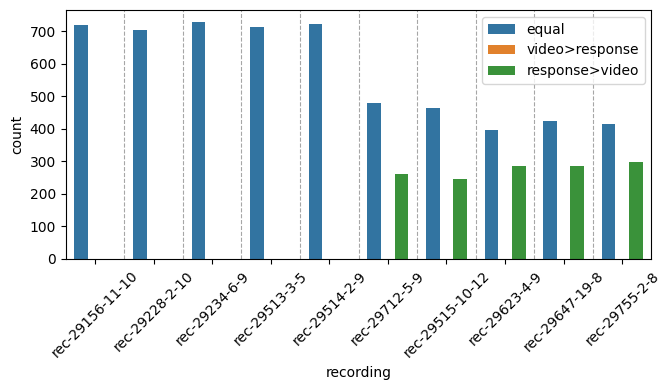

In [33]:
result["recording_short_label"] = result["recording"].map(mapping)
rec_order = [mapping[rec] for rec in all_recording_folders]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=result, x="recording_short_label", y="count", hue="relation", order=rec_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.7)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("recording")
ax.legend()
# Add vertical lines between x groups
n_groups = len(result["recording_short_label"].unique())
for i in range(n_groups - 1):
    ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-recording.png"), dpi=300)
plt.show()


In [34]:
min_diff = np.min(trials_df["valid_frames_diff"].to_numpy())
max_diff = np.max(trials_df["valid_frames_diff"].to_numpy())
print(f"range for valid_frames_diff [{min_diff}, {max_diff}]")

range for valid_frames_diff [-114, 0]


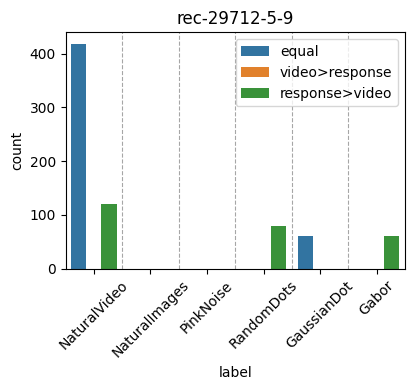

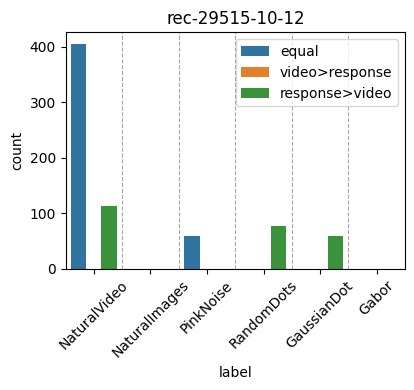

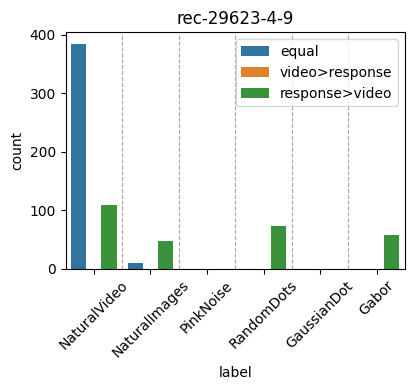

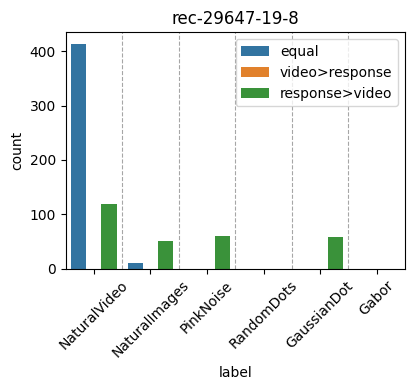

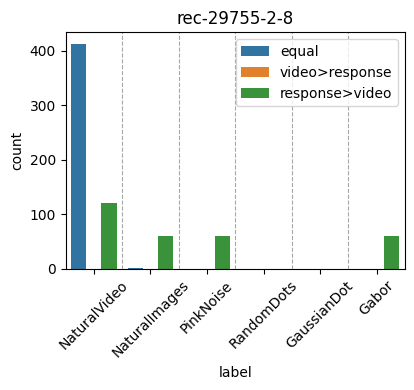

In [35]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
for rec in ds.recording:
    df = trials_df[trials_df['recording']==rec]
    if any(df["valid_frames_diff"]!=0):
        result_rec = (
        df.groupby("label")["valid_frames_diff"]
        .apply(lambda x: {
            "video>response": (x > 0).sum(),
            "response>video": (x < 0).sum(),
            "equal":     (x == 0).sum()
        })
        .apply(pd.Series)
        .reset_index()
        )
        result_rec.columns = ["label", "relation", "count"]

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.barplot(data=result_rec, x="label", y="count", hue="relation", order=labels_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.8)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel("label")
        ax.legend()
        ax.set_title(mapping[rec])
        # Add vertical lines between x groups
        n_groups = len(labels_order)
        for i in range(n_groups - 1):
            ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

        fig.tight_layout(rect=[0, 0, 0.85, 1])
        fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-label_rec-{mapping[rec]}.png"), dpi=300)
        plt.show()

   
    

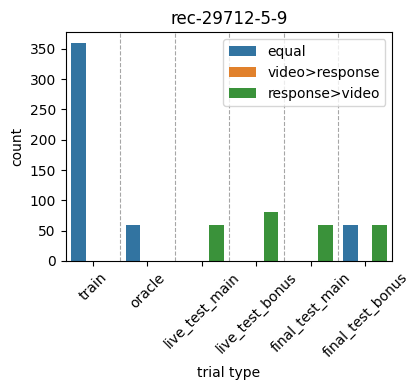

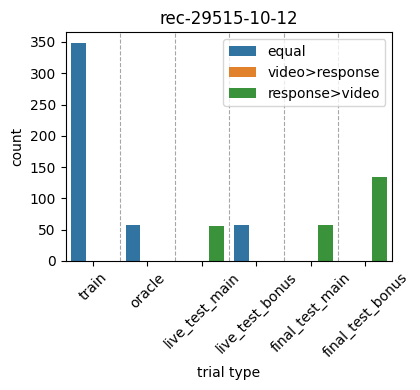

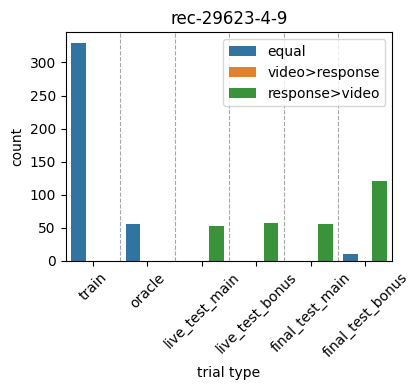

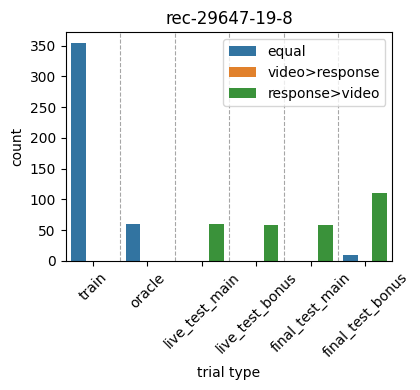

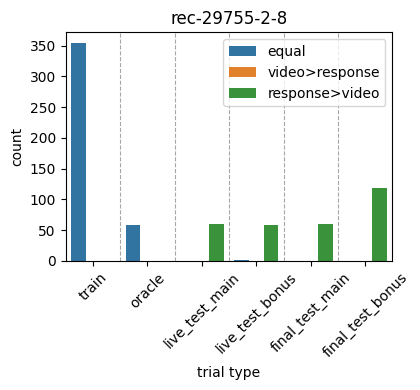

In [36]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
trials_order = ["train", "oracle","live_test_main","live_test_bonus","final_test_main","final_test_bonus"]

for rec in ds.recording:
    df = trials_df[trials_df['recording']==rec]
    if any(df["valid_frames_diff"]!=0):
        result_rec = (
        df.groupby("trial_type")["valid_frames_diff"]
        .apply(lambda x: {
            "video>response": (x > 0).sum(),
            "response>video": (x < 0).sum(),
            "equal":     (x == 0).sum()
        })
        .apply(pd.Series)
        .reset_index()
        )
        result_rec.columns = ["trial_type", "relation", "count"]

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.barplot(data=result_rec, x="trial_type", y="count", hue="relation", order=trials_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.8)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel("trial type")
        ax.legend()
        ax.set_title(mapping[rec])
        # Add vertical lines between x groups
        n_groups = len(trials_order)
        for i in range(n_groups - 1):
            ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

        fig.tight_layout(rect=[0, 0, 0.85, 1])
        fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-trial-type_rec-{mapping[rec]}.png"), dpi=300)
        plt.show()


## Trials with same ID and different valid frames

### For the trial valid frames

In [37]:
result_trials = trials_df.groupby("video_ID")["valid_frames"].nunique()
result_trials = result_trials.reset_index()
result_trials.columns = ["video_ID", "count"]
result_trials.loc[result_trials["count"]>1]


,video_ID,count
200,v098651,2
269,v139482,2
1175,v582341,2
1920,v969497,2


### For the video valid frames

In [38]:
result_video = trials_df.groupby("video_ID")["valid_frames_video"].nunique()
result_video = result_video.reset_index()
result_video.columns = ["video_ID", "count"]
result_video.loc[result_video["count"]>1]


,video_ID,count
200,v098651,2
269,v139482,2
1175,v582341,2
1920,v969497,2


### For the response valid frames

In [39]:
result_resp = trials_df.groupby("video_ID")["valid_frames_response"].nunique()
result_resp = result_resp.reset_index()
result_resp.columns = ["video_ID", "count"]
result_resp.loc[result_resp["count"]>1]

,video_ID,count
4,v001128,2
5,v001281,2
11,v003131,2
34,v011459,2
36,v013217,2
...,...,...
1920,v969497,3
1939,v980183,2
1954,v985936,2
1972,v993094,2


### Inspect some videos with same ID and different valid frames

In [47]:
ID = "v098651"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2233,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,682,live_test_bonus,319,True,319,319,True
2349,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,675,live_test_bonus,319,True,319,319,True
2389,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,710,live_test_bonus,319,True,319,319,True
2464,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,712,live_test_bonus,319,True,319,319,True
2521,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,666,live_test_bonus,319,True,319,319,True
2543,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,690,live_test_bonus,319,True,319,319,True
2586,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,692,live_test_bonus,319,True,319,319,True
2591,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,670,live_test_bonus,321,True,321,321,True
2621,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,708,live_test_bonus,319,True,319,319,True
2771,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,672,live_test_bonus,319,True,319,319,True


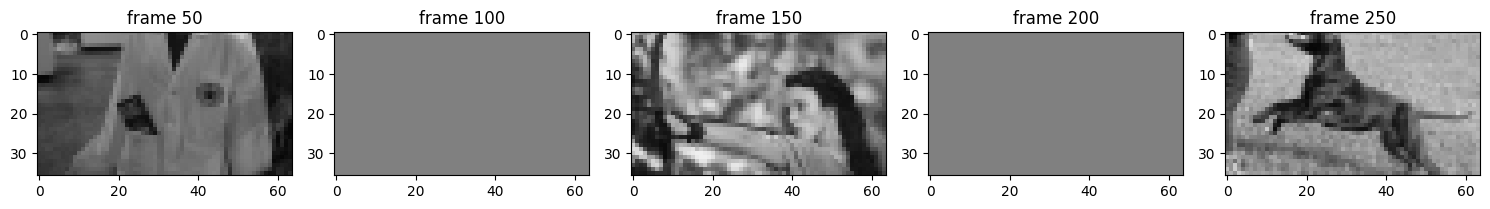

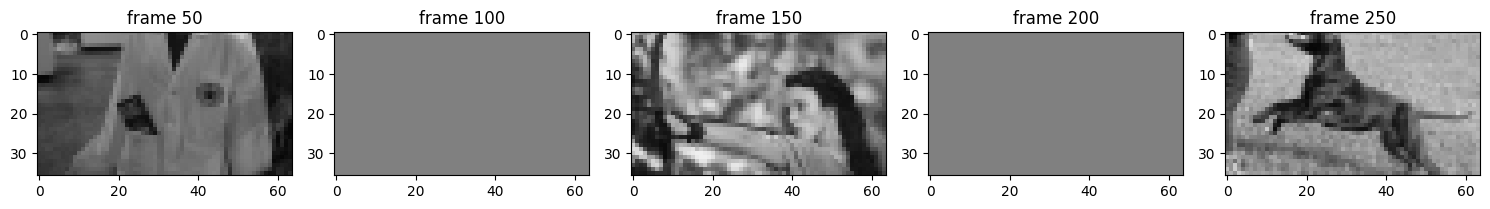

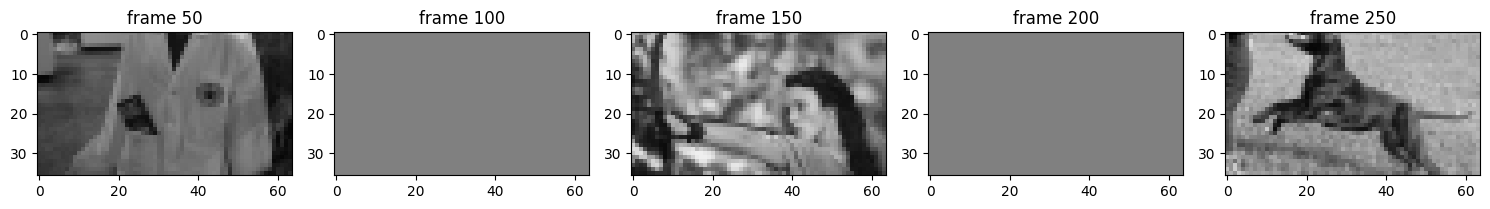

In [48]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='682', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='670', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='148', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)


In [49]:
ID = "v139482"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2211,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,716,live_test_bonus,310,True,310,310,True
2287,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,671,live_test_bonus,310,True,310,310,True
2311,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,688,live_test_bonus,310,True,310,310,True
2328,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,673,live_test_bonus,310,True,310,310,True
2462,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,698,live_test_bonus,310,True,310,310,True
2627,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,678,live_test_bonus,310,True,310,310,True
2650,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,677,live_test_bonus,310,True,310,310,True
2677,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,703,live_test_bonus,310,True,310,310,True
2753,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,718,live_test_bonus,310,True,310,310,True
2816,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,687,live_test_bonus,311,True,311,311,True


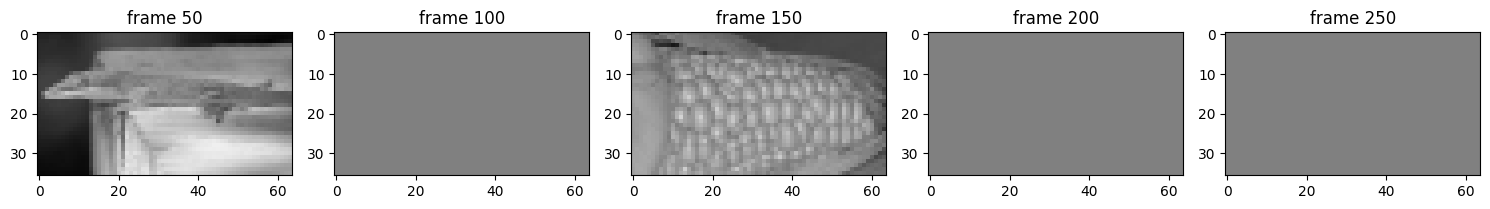

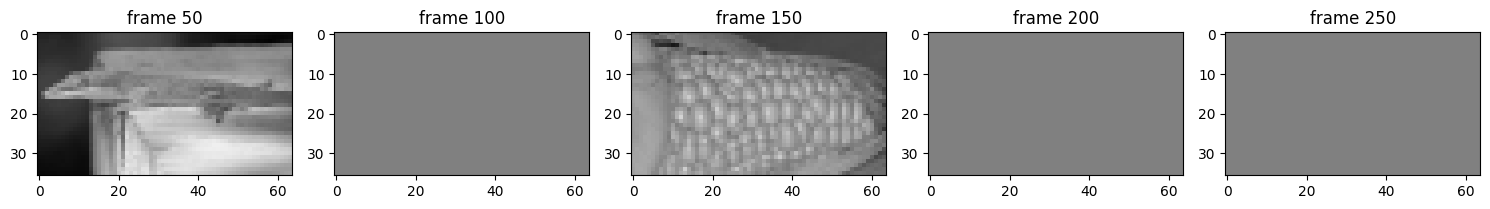

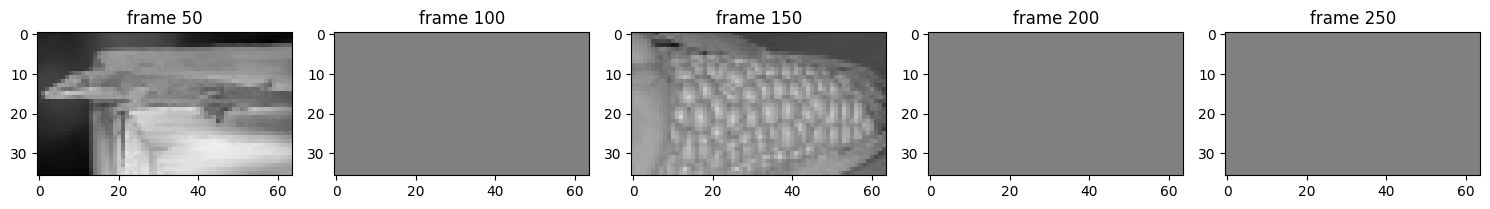

In [50]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='716', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='687', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='256', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)

In [52]:
ID = "v582341"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2160,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,685,live_test_bonus,306,True,306,306,True
2249,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,693,live_test_bonus,306,True,306,306,True
2391,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,705,live_test_bonus,306,True,306,306,True
2519,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,702,live_test_bonus,305,True,305,305,True
2537,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,681,live_test_bonus,305,True,305,305,True
2659,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,689,live_test_bonus,305,True,305,305,True
2793,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,719,live_test_bonus,305,True,305,305,True
2852,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,717,live_test_bonus,305,True,305,305,True
5765,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v582341,314,final_test_bonus,306,True,306,326,False
5820,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v582341,693,final_test_bonus,305,True,305,326,False


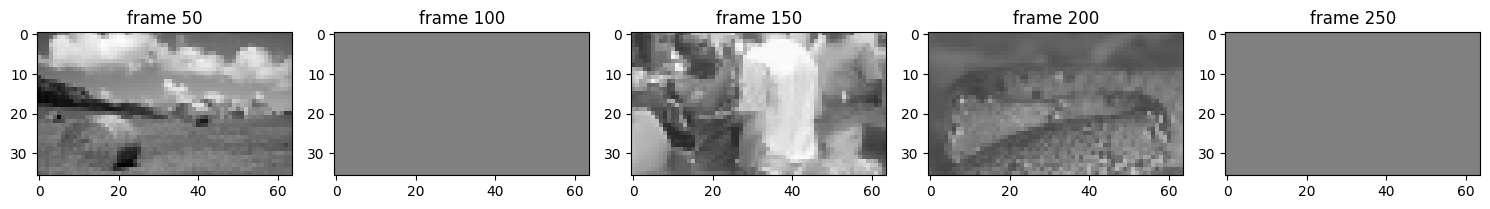

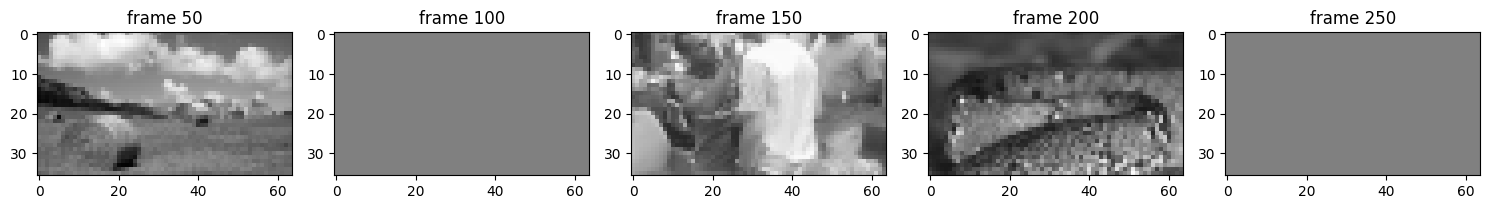

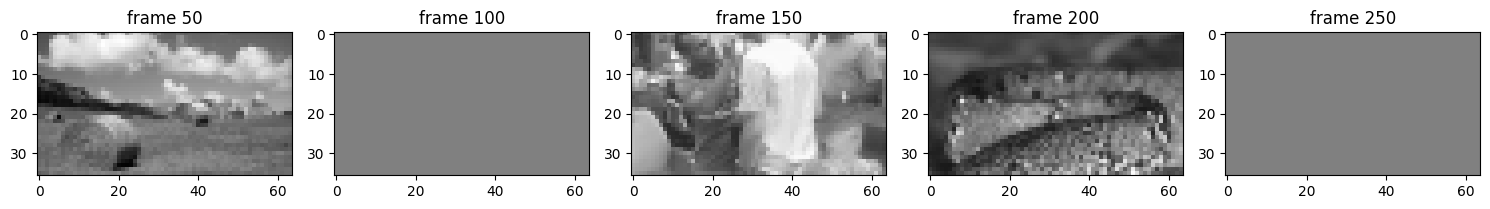

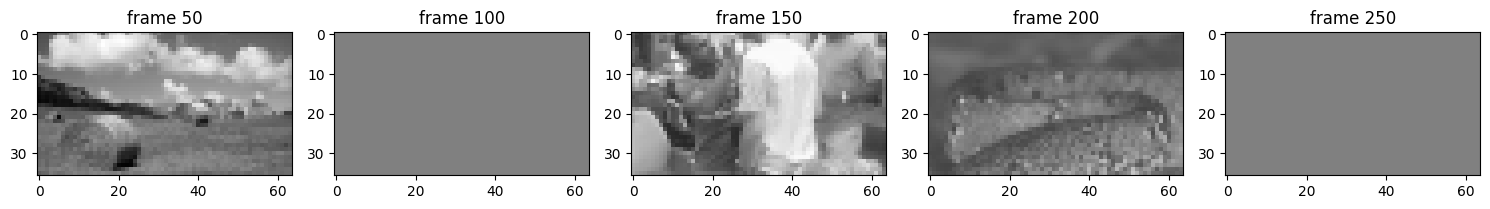

In [53]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='685', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='681', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='693', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='314', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)

In [54]:
ID = "v969497"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2176,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,665,live_test_bonus,313,True,313,313,True
2274,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,707,live_test_bonus,312,True,312,312,True
2361,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,684,live_test_bonus,313,True,313,313,True
2365,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,683,live_test_bonus,313,True,313,313,True
2529,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,660,live_test_bonus,313,True,313,313,True
2556,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,701,live_test_bonus,313,True,313,313,True
2727,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,715,live_test_bonus,313,True,313,313,True
2752,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,697,live_test_bonus,313,True,313,313,True
2795,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,695,live_test_bonus,312,True,312,312,True
2823,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,661,live_test_bonus,313,True,313,313,True


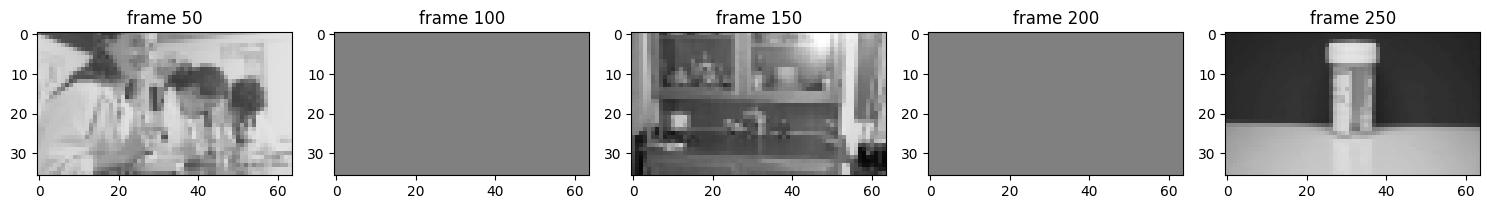

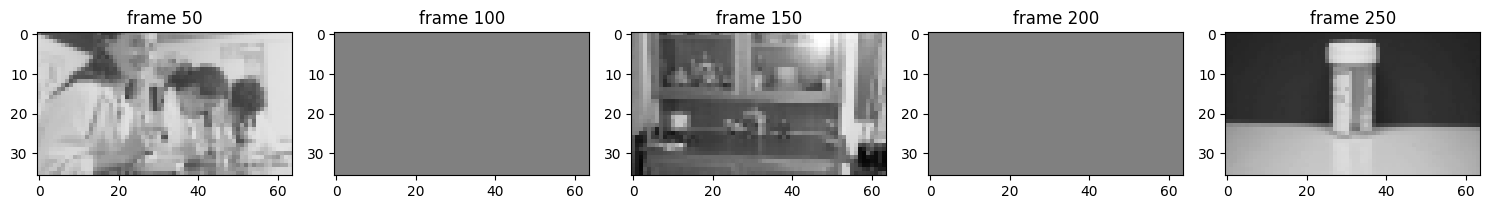

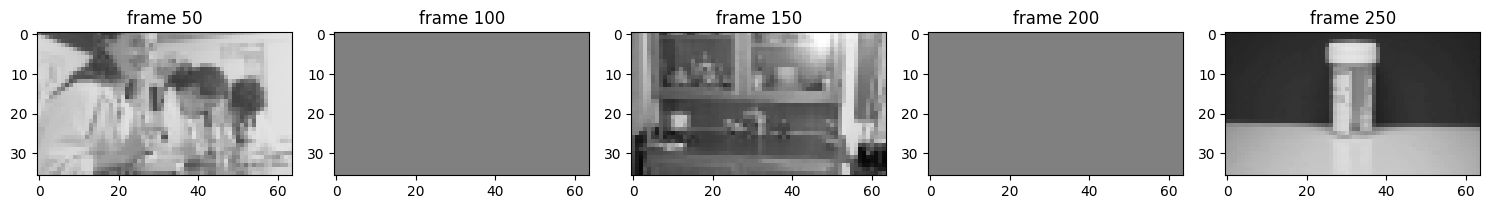

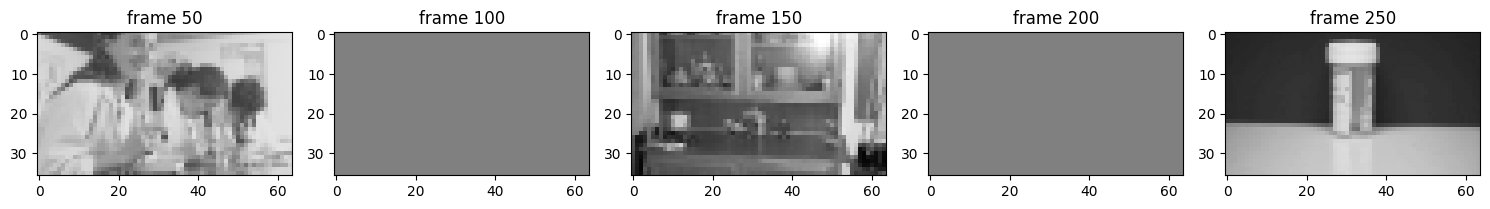

In [55]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='665', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='707', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='209', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='600', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)